<a href="https://www.kaggle.com/code/shreeyashah/imdb-reviews?scriptVersionId=317542414" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [2]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras

2026-05-08 06:03:09.993335: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778220190.206382      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778220190.264420      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778220190.770104      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778220190.770148      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778220190.770152      57 computation_placer.cc:177] computation placer alr

In [3]:
df = pd.read_csv("/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
X = df.iloc[:,0]
y = df.iloc[:,1]

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y)

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(num_words = 10000, oov_token='<nothing>')

In [8]:
tokenizer.fit_on_texts(X_train)

In [9]:
X_train_seq = tokenizer.texts_to_sequences(X_train)

In [10]:
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [27]:
total_words = total_words = len(tokenizer.word_index) + 1

In [29]:
max_len = max([len(x) for x in X_train_seq])

In [11]:
from keras.utils import pad_sequences
X_train_seq = pad_sequences(X_train_seq, padding = 'post', maxlen = max_len)
X_test_seq = pad_sequences(X_test_seq, padding = 'post', maxlen = max_len)

In [12]:
from tensorflow.keras import layers
from keras.layers import Embedding, Dense, LSTM, Input
from keras.models import Sequential

In [46]:
model = Sequential()
model.add(Embedding(total_words , output_dim = 100, input_length=250))
model.add(LSTM(150))
model.add(Dense(1, activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [47]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [48]:
history = model.fit(X_train_seq, y_train, epochs = 5, validation_split = 0.2)

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.5323 - loss: 0.6871 - val_accuracy: 0.4709 - val_loss: 0.6970
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.6391 - loss: 0.5966 - val_accuracy: 0.8733 - val_loss: 0.2940
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.9067 - loss: 0.2347 - val_accuracy: 0.8971 - val_loss: 0.2564
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.9516 - loss: 0.1364 - val_accuracy: 0.8726 - val_loss: 0.3343
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.9730 - loss: 0.0872 - val_accuracy: 0.8904 - val_loss: 0.3441


In [50]:
y_pred = model.predict(X_test_seq)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [51]:
y_pred = np.where(y_pred>=0.5,1 , 0)

In [52]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8817

In [53]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[4535,  465],
       [ 718, 4282]])

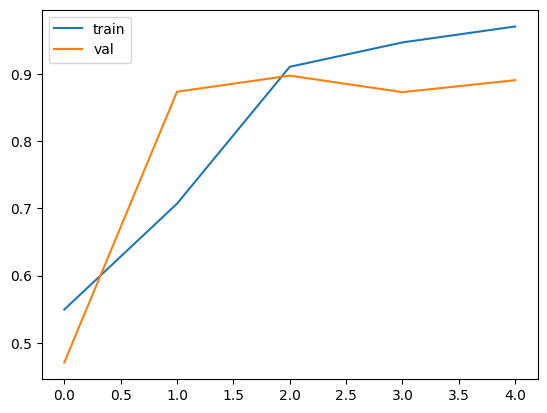

In [54]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label = 'train')
plt.plot(history.history['val_accuracy'], label = 'val')
plt.legend()
plt.show()

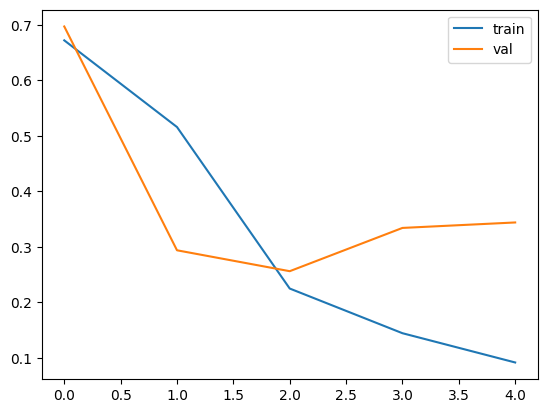

In [55]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label = 'val')
plt.legend()
plt.show()